# Vehicle Insurance Fraud Detection
## Goal
Automatically detect fraudulent insurance claims using machine learning - catching 96% of fraud cases.

# Dataset
15,420 insurance record | 33 features| 6% fraud rate
Source: Kaggle - Vehicle Claim Fraud Detection

## Results
|
 Metric
|
 Score
|
|
---
|
---
|
|
 Recall (Fraud)
|
 96%
|
|
 AUC-ROC
|
 0.98
|
|
 F1-Score
|
 90%
|

In [ ]:
from google.colab import files

files.upload()

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve
from imblearn.over_sampling import SMOTE

In [5]:
raw_data = pd.read_csv("fraud_vehicle/fraud_oracle.csv")
raw_data

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15415,Nov,4,Friday,Toyota,Urban,Tuesday,Nov,5,Male,Married,...,6 years,31 to 35,No,No,External,none,no change,1 vehicle,1996,Collision
15416,Nov,5,Thursday,Pontiac,Urban,Friday,Dec,1,Male,Married,...,6 years,31 to 35,No,No,External,more than 5,no change,3 to 4,1996,Liability
15417,Nov,5,Thursday,Toyota,Rural,Friday,Dec,1,Male,Single,...,5 years,26 to 30,No,No,External,1 to 2,no change,1 vehicle,1996,Collision
15418,Dec,1,Monday,Toyota,Urban,Thursday,Dec,2,Female,Married,...,2 years,31 to 35,No,No,External,more than 5,no change,1 vehicle,1996,All Perils


In [4]:
raw_data.shape

(15420, 33)

In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [6]:
raw_data.describe().T

,count,mean,std,min,25%,50%,75%,max
WeekOfMonth,15420.0,2.788586,1.287585,1.0,2.00,3.0,4.00,5.0
WeekOfMonthClaimed,15420.0,2.693969,1.259115,1.0,2.00,3.0,4.00,5.0
Age,15420.0,39.855707,13.492377,0.0,31.00,38.0,48.00,80.0
FraudFound_P,15420.0,0.059857,0.237230,0.0,0.00,0.0,0.00,1.0
PolicyNumber,15420.0,7710.500000,4451.514911,1.0,3855.75,7710.5,11565.25,15420.0
RepNumber,15420.0,8.483268,4.599948,1.0,5.00,8.0,12.00,16.0
Deductible,15420.0,407.704280,43.950998,300.0,400.00,400.0,400.00,700.0
DriverRating,15420.0,2.487808,1.119453,1.0,1.00,2.0,3.00,4.0
Year,15420.0,1994.866472,0.803313,1994.0,1994.00,1995.0,1996.00,1996.0


In [7]:
raw_data.isnull().sum()

,0
Month,0
WeekOfMonth,0
DayOfWeek,0
Make,0
AccidentArea,0
DayOfWeekClaimed,0
MonthClaimed,0
WeekOfMonthClaimed,0
Sex,0
MaritalStatus,0


In [8]:
def summarize(DataFrame):

    summary = pd.DataFrame()

    # Data Type
    summary['Data Type'] = DataFrame.dtypes
    # N Unique
    summary['N Unique'] = DataFrame.nunique()
    # Unique
    summary['Unique'] = DataFrame.apply(lambda x: x.unique().tolist())
    # Max
    summary['Max'] = DataFrame.apply(lambda x: x.max() if pd.api.types.is_numeric_dtype(x) else '-')
    # Min
    summary['Min'] = DataFrame.apply(lambda x: x.min() if pd.api.types.is_numeric_dtype(x) else '-')

    # Measures of Central Tendency: Mean, Median, Mode
    summary['Mean'] = DataFrame.apply(lambda x: round(x.mean(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Median'] = DataFrame.apply(lambda x: x.median() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Mode'] = DataFrame.apply(lambda x: x.mode().iloc[0] if not x.mode().empty else '-')

    # Measures of Dispersion: Range, Variance, Standard Deviation
    summary['Range'] = DataFrame.apply(lambda x: x.max() - x.min() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Variance'] = DataFrame.apply(lambda x: x.var() if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Standard Deviation'] = DataFrame.apply(lambda x: x.std() if pd.api.types.is_numeric_dtype(x) else '-')

    # Measures of Shape: Skewness, Kurtosis
    summary['Skewness'] = DataFrame.apply(lambda x: round(x.skew(), 2) if pd.api.types.is_numeric_dtype(x) else '-')
    summary['Kurtosis'] = DataFrame.apply(lambda x: round(x.kurt(), 2) if pd.api.types.is_numeric_dtype(x) else '-')

    return summary

In [9]:
summarize(raw_data)

,Data Type,N Unique,Unique,Max,Min,Mean,Median,Mode,Range,Variance,Standard Deviation,Skewness,Kurtosis
Month,object,12,"[Dec, Jan, Oct, Jun, Feb, Nov, Apr, Mar, Aug, ...",-,-,-,-,Jan,-,-,-,-,-
WeekOfMonth,int64,5,"[5, 3, 2, 4, 1]",5,1,2.79,3.0,3,4,1.657876,1.287585,0.12,-1.1
DayOfWeek,object,7,"[Wednesday, Friday, Saturday, Monday, Tuesday,...",-,-,-,-,Monday,-,-,-,-,-
Make,object,19,"[Honda, Toyota, Ford, Mazda, Chevrolet, Pontia...",-,-,-,-,Pontiac,-,-,-,-,-
AccidentArea,object,2,"[Urban, Rural]",-,-,-,-,Urban,-,-,-,-,-
DayOfWeekClaimed,object,8,"[Tuesday, Monday, Thursday, Friday, Wednesday,...",-,-,-,-,Monday,-,-,-,-,-
MonthClaimed,object,13,"[Jan, Nov, Jul, Feb, Mar, Dec, Apr, Aug, May, ...",-,-,-,-,Jan,-,-,-,-,-
WeekOfMonthClaimed,int64,5,"[1, 4, 2, 3, 5]",5,1,2.69,3.0,2,4,1.585371,1.259115,0.16,-1.09
Sex,object,2,"[Female, Male]",-,-,-,-,Male,-,-,-,-,-
MaritalStatus,object,4,"[Single, Married, Widow, Divorced]",-,-,-,-,Married,-,-,-,-,-


## EDA

In [10]:
fraud_counts = raw_data["FraudFound_P"].value_counts().reset_index()
fraud_counts.columns = ["FraudFound_P", "Count"]
fraud_counts

,FraudFound_P,Count
0,0,14497
1,1,923


Target data is highly imbalanced.

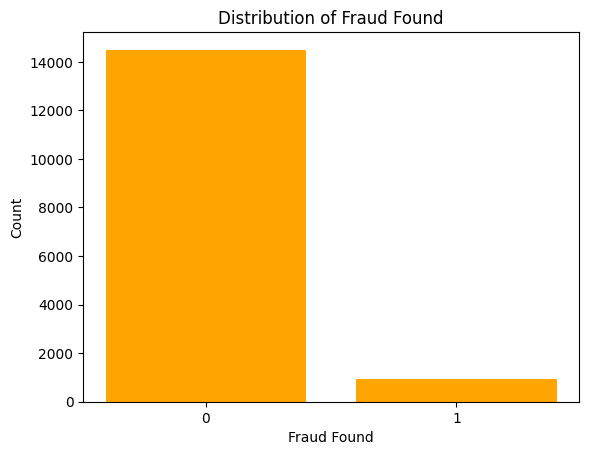

In [11]:
plt.bar(data=fraud_counts, x="FraudFound_P", height="Count", color="orange")

plt.title("Distribution of Fraud Found")
plt.xlabel("Fraud Found")
plt.ylabel("Count")

plt.xticks([0, 1])

plt.show()

Fraud Detection by sex

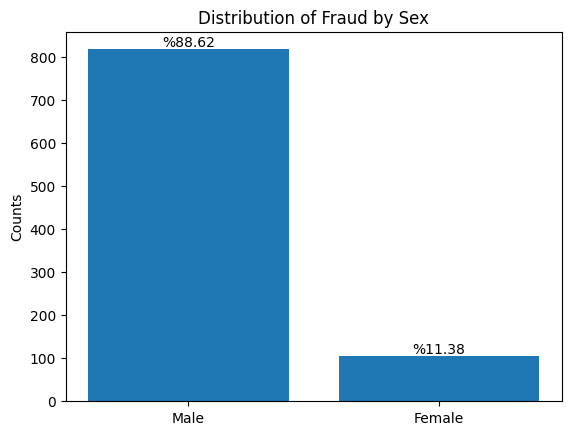

In [12]:
df_fraud = raw_data[raw_data["FraudFound_P"] == 1]
fraud_counts_sex = df_fraud["Sex"].value_counts()


fig, ax = plt.subplots()

bar_container = ax.bar(data=fraud_counts_sex, x=fraud_counts_sex.index, height= fraud_counts_sex.values)
ax.bar_label(bar_container, fmt=lambda x: f"%{x / fraud_counts_sex.sum() * 100:.2f}")
ax.set(ylabel="Counts", title="Distribution of Fraud by Sex")


plt.show()

Fraud Detection with Age

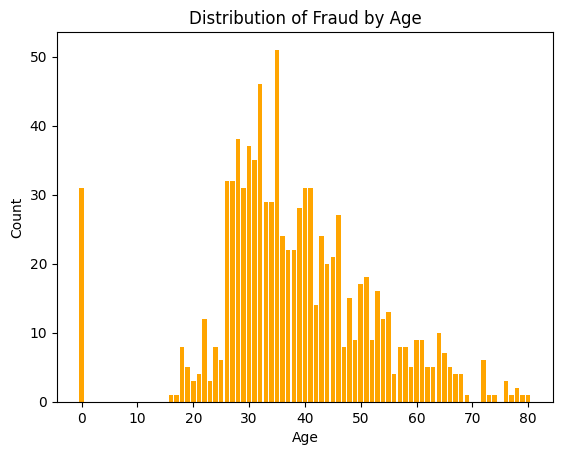

In [13]:
df_fraud = raw_data[raw_data["FraudFound_P"] == 1]
df_notfraud = raw_data[raw_data["FraudFound_P"] == 0]

fraud_age_counts = df_fraud["Age"].value_counts()
plt.bar(data=fraud_age_counts, x=fraud_age_counts.index, height=fraud_age_counts.values, color="orange")

plt.title("Distribution of Fraud by Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

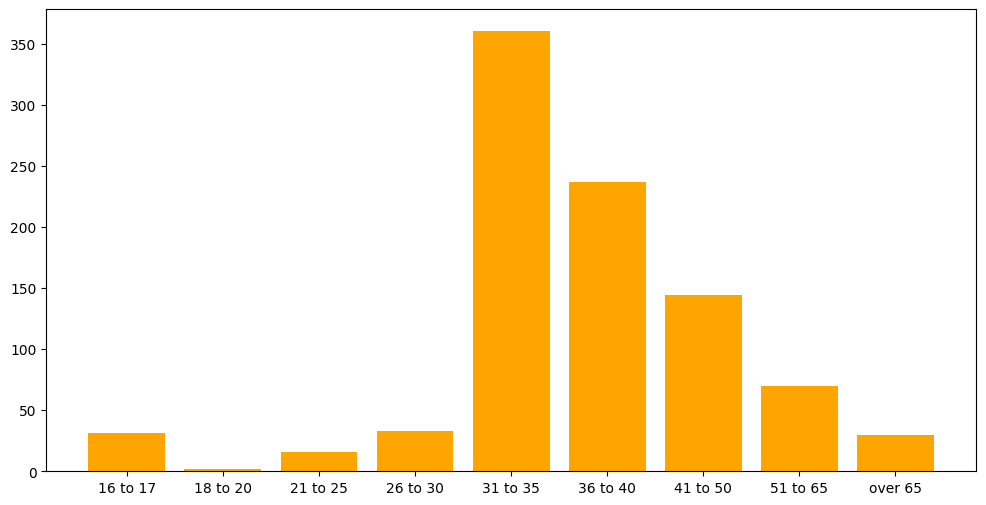

In [14]:
fraud_age_counts = df_fraud["AgeOfPolicyHolder"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(data=fraud_age_counts, x=fraud_age_counts.index, height=fraud_age_counts.values, color="orange")


plt.show()

Fraud Detection by make

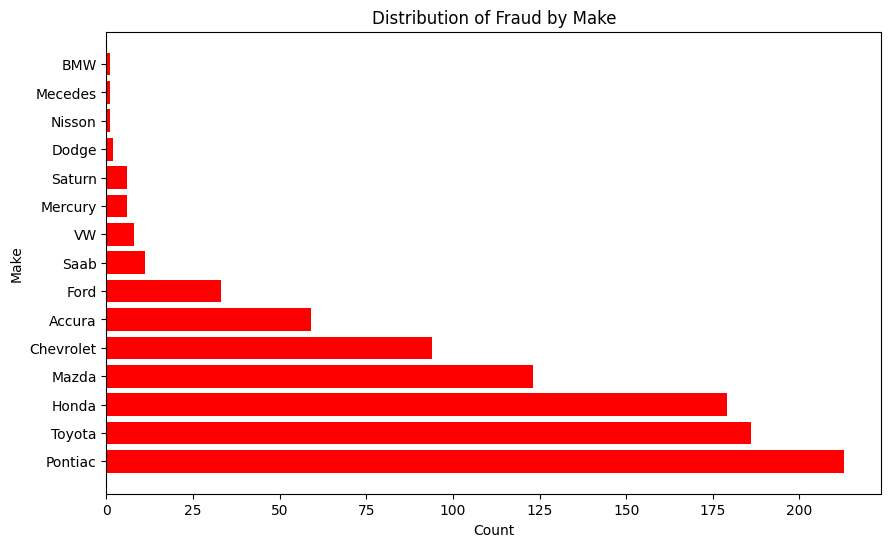

In [15]:
fraud_make_counts = df_fraud["Make"].value_counts()

plt.figure(figsize=(10, 6))

plt.barh(data=fraud_make_counts, y=fraud_make_counts.index, width=fraud_make_counts.values, color="red")
plt.title("Distribution of Fraud by Make")
plt.ylabel("Make")
plt.xlabel("Count")

plt.show()


## Preprocessing
1. Binary variables --> Label encoding

In [16]:
df_clean_v1 = raw_data.copy()
df_clean_v1.shape

(15420, 33)

In [17]:
binary_columns = [col for col in df_clean_v1.columns if df_clean_v1[col].nunique() == 2 and col != "FraudFound_P"]

print(f"The number of binary columns: {len(binary_columns)}")
print(binary_columns)

The number of binary columns: 6
['AccidentArea', 'Sex', 'Fault', 'PoliceReportFiled', 'WitnessPresent', 'AgentType']


In [18]:
le = LabelEncoder()

for col in binary_columns:
  df_clean_v1[col] = le.fit_transform(df_clean_v1[col])
  print(f"Label mapping for ({col}): {dict(zip(le.classes_, le.transform(le.classes_)))}")

Label mapping for (AccidentArea): {'Rural': np.int64(0), 'Urban': np.int64(1)}
Label mapping for (Sex): {'Female': np.int64(0), 'Male': np.int64(1)}
Label mapping for (Fault): {'Policy Holder': np.int64(0), 'Third Party': np.int64(1)}
Label mapping for (PoliceReportFiled): {'No': np.int64(0), 'Yes': np.int64(1)}
Label mapping for (WitnessPresent): {'No': np.int64(0), 'Yes': np.int64(1)}
Label mapping for (AgentType): {'External': np.int64(0), 'Internal': np.int64(1)}


2. Encoding Categorical variables (ordinal and numinal)

In [19]:
for col in ['VehiclePrice', 'DriverRating', 'AgeOfVehicle', 'BasePolicy']:
    print(f"The unique values in {col}: {df_clean_v1[col].unique()}")

The unique values in VehiclePrice: ['more than 69000' '20000 to 29000' '30000 to 39000' 'less than 20000'
 '40000 to 59000' '60000 to 69000']
The unique values in DriverRating: [1 4 3 2]
The unique values in AgeOfVehicle: ['3 years' '6 years' '7 years' 'more than 7' '5 years' 'new' '4 years'
 '2 years']
The unique values in BasePolicy: ['Liability' 'Collision' 'All Perils']


In [20]:
vehicleprice_label = {'more than 69000': 1, '20000 to 29000': 0,  '30000 to 39000': 0, 'less than 20000': 1, '40000 to 59000': 1, '60000 to 69000': 0}
ageofvehicle_label = {'new': 2, '2 years': 0, '3 years': 2, '4 years': 2, '5 years': 1, '6 years': 1, '7 years': 0, 'more than 7': 0}
basepolicy_label = {'Liability': 0, 'Collision': 1, 'All Perils': 2}

In [21]:
df_clean_v1['VehiclePrice'] = df_clean_v1['VehiclePrice'].map(vehicleprice_label)
df_clean_v1['AgeOfVehicle'] = df_clean_v1['AgeOfVehicle'].map(ageofvehicle_label)
df_clean_v1['BasePolicy'] = df_clean_v1['BasePolicy'].map(basepolicy_label)

In [22]:
df_clean_v2 = df_clean_v1.copy()
df_clean_v2.shape

(15420, 33)

3. Data Reduction --> Feature Selection(Drop Useless columns)

In [23]:
useless_columns = ['Month', 'WeekOfMonth', 'DayOfWeek', 'DayOfWeekClaimed', 'WeekOfMonthClaimed', 'PolicyNumber']
df_clean_v3 = df_clean_v2.drop(columns=useless_columns, axis=1)
df_clean_v3.shape

(15420, 27)

4. Data Transformation --> One-Hot Encoding (Other categorical variables)

In [24]:
dtype_change_string = ['RepNumber', 'Deductible', 'Year']
for col in dtype_change_string:
    df_clean_v3[col] = df_clean_v3[col].astype(str)

In [25]:
onehot_encoding_columns = ['Make', 'MonthClaimed', 'MaritalStatus', 'PolicyType', 'VehicleCategory', 'RepNumber', 'Deductible', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfPolicyHolder', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year']
print("The number of one-hot encoding target features: ", len(onehot_encoding_columns))

The number of one-hot encoding target features:  15


In [26]:
df_clean_v4 = pd.get_dummies(df_clean_v3, columns=onehot_encoding_columns)
df_clean_v4.shape

(15420, 119)

5. Data reduction --> Feature Selection (Drop Constant Features)

In [27]:
onehot_encoded_columns = [col for col in df_clean_v4.columns if '_' in col]
onehot_encoded_columns.remove("FraudFound_P")
print("The Number of One-hot Encoded Columns: ", len(onehot_encoded_columns))

The Number of One-hot Encoded Columns:  107


In [28]:
constant_features = []
for col in onehot_encoded_columns:
    if df_clean_v4[col].sum() <= 5:
        constant_features.append(col)
print("The Number of Constant Features: ", len(constant_features))
print(constant_features)

The Number of Constant Features:  9
['Make_Ferrari', 'Make_Lexus', 'Make_Mecedes', 'Make_Porche', 'MonthClaimed_0', 'PolicyType_Sport - Liability', 'Days_Policy_Claim_none', 'AddressChange_Claim_under 6 months', 'NumberOfCars_more than 8']


In [29]:
df_clean_v4.drop(columns=constant_features, axis=1, inplace=True)
df_clean_v4.shape

(15420, 110)

6. Data cleaning --> Correcting inaccurate data and handling outliers (Age)

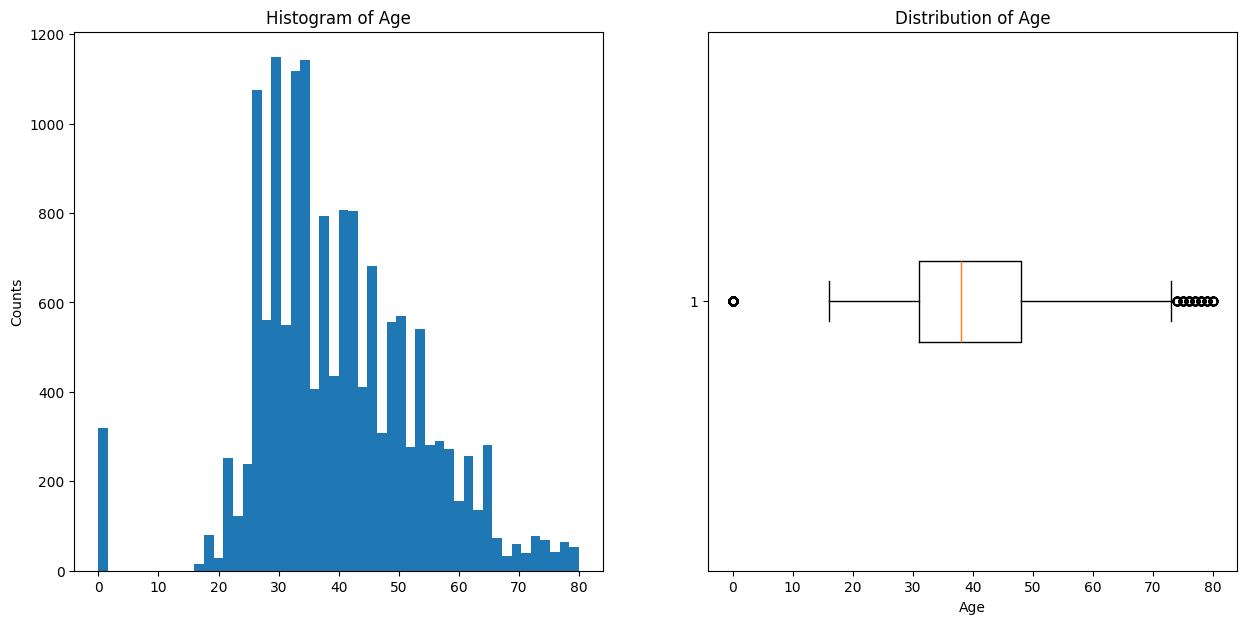

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

ax = axes[0]
ax.hist(df_clean_v4["Age"], bins=50)
ax.set_title("Histogram of Age")
ax.set_ylabel("Counts")

ax = axes[1]
ax.boxplot(df_clean_v4['Age'], orientation='horizontal')
ax.set_title("Boxplot of Age")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.show()

In [31]:
Q1 = df_clean_v4["Age"].quantile(0.25)
Q3 = df_clean_v4["Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean_v5 = df_clean_v4[(df_clean_v4["Age"] >= lower_bound) & (df_clean_v4["Age"] <= upper_bound)]
df_clean_v5.shape

(14873, 110)

In [32]:
def categorize_age(age):
    if age <= 20:
        return 0
    elif age <= 40:
        return 1
    elif age <= 65:
        return 2
    else:
        return 3

In [33]:
df_clean_v5['Age'] = df_clean_v5['Age'].apply(categorize_age)

/tmp/ipython-input-4141984253.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean_v5['Age'] = df_clean_v5['Age'].apply(categorize_age)


In [34]:
df_clean_v5["Age"]

,Age
0,1
1,1
2,2
3,2
4,1
...,...
15415,1
15416,1
15417,1
15418,1


### Handling imbalanced target data

In [35]:
X = df_clean_v5.drop(columns="FraudFound_P", axis=1)
y = df_clean_v5["FraudFound_P"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
smote = SMOTE(random_state=0)
x_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {X_train.shape}, {y_train.shape}")
print(f"After SMOTE: {x_train_resampled.shape}, {y_train_resampled.shape}")

print(f"After SMOTE Label Distribution: {pd.Series(y_train_resampled).value_counts()}")

Before SMOTE: (11898, 109), (11898,)
After SMOTE: (22392, 109), (22392,)
After SMOTE Label Distribution: FraudFound_P
0    11196
1    11196
Name: count, dtype: int64


In [37]:
df_smote = pd.concat([x_train_resampled, y_train_resampled], axis=1)
df_smote.shape

(22392, 110)

## Modeling

In [38]:
X = df_smote.drop(columns="FraudFound_P", axis=1)
y = df_smote["FraudFound_P"]

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
classifier = RandomForestClassifier(n_estimators=700, max_depth=12, min_samples_split=6, min_samples_leaf=5, verbose=1, random_state=42,
                                    bootstrap=True, max_features="log2")

In [53]:
model = classifier.fit(x_train, y_train)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    3.0s
[Parallel(n_jobs=1)]: Done 700 out of 700 | elapsed:    4.7s finished


In [54]:
y_pred = model.predict(x_test)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 700 out of 700 | elapsed:    0.3s finished


In [55]:
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred)}")
print(f"Recall: {recall_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred)}")

Accuracy: 0.8903773163652601
Precision: 0.8402555910543131
Recall: 0.9585421412300683
F1 Score: 0.8955096829112578


In [45]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rf = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [300, 400, 500, 600, 700, 800],
    'max_depth': [8, 9, 10, 11, 12, 13],
    'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'max_features': ["sqr", "log2", None],
    "bootstrap": [True, False] }

random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist, n_iter=10, scoring="f1", cv=3, verbose=2, random_state=42, n_jobs=-1)

random_search.fit(x_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
6 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_pa

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'bootstrap': [True, False],
                                        'max_depth': [8, 9, 10, 11, 12, 13],
                                        'max_features': ['sqr', 'log2', None],
                                        'min_samples_leaf': [1, 2, 3, 4, 5, 6,
                                                             7, 8, 9, 10],
                                        'min_samples_split': [2, 3, 4, 5, 6, 7,
                                                              8, 9, 10, 11, 12,
                                                              13, 14, 15],
                                        'n_estimators': [300, 400, 500, 600,
                                                         700, 800]},
                   random_state=42, scoring='f1', verbose=2)

In [47]:
print(f"Best Params: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

Best Params: {'n_estimators': 700, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 12, 'bootstrap': True}
Best Score: 0.8942256808251074


## Results

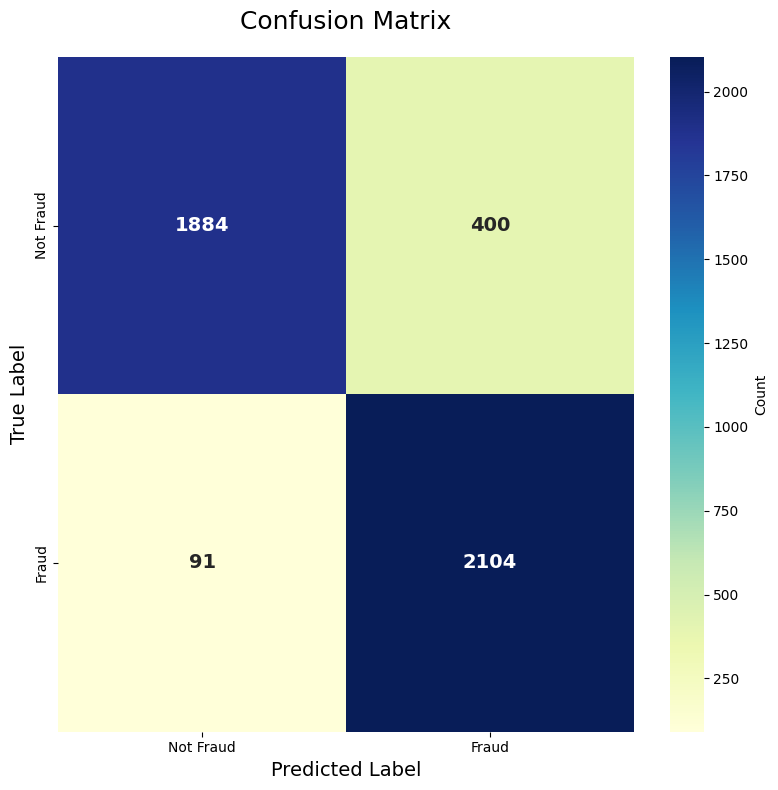

In [85]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt="d", cbar=True, xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"], cmap="YlGnBu",
            annot_kws={"size": 14, "weight": "bold"}, cbar_kws={"label": "Count"})

plt.title("Confusion Matrix", fontsize=18, pad=20)

plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)

plt.tight_layout()
plt.show()

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 700 out of 700 | elapsed:    0.4s finished


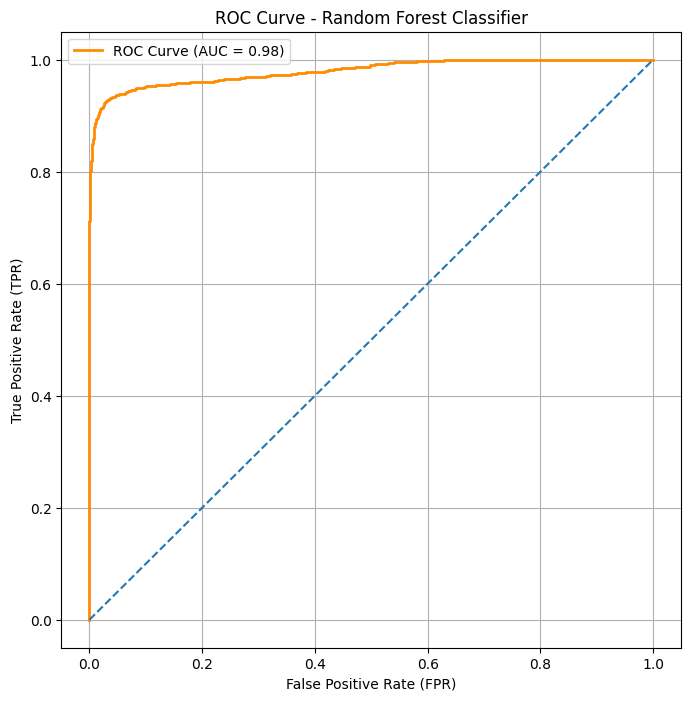

In [60]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 8))

plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Random Forest Classifier")

plt.legend()
plt.grid(True)
plt.show()

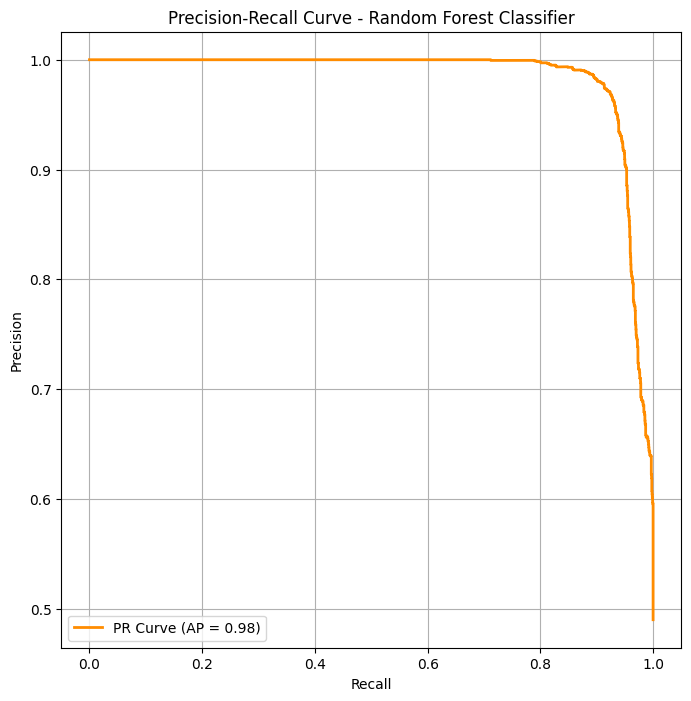

In [61]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 8))

plt.plot(recall, precision, color="darkorange", lw=2, label=f"PR Curve (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest Classifier")

plt.legend()
plt.grid(True)

plt.show()

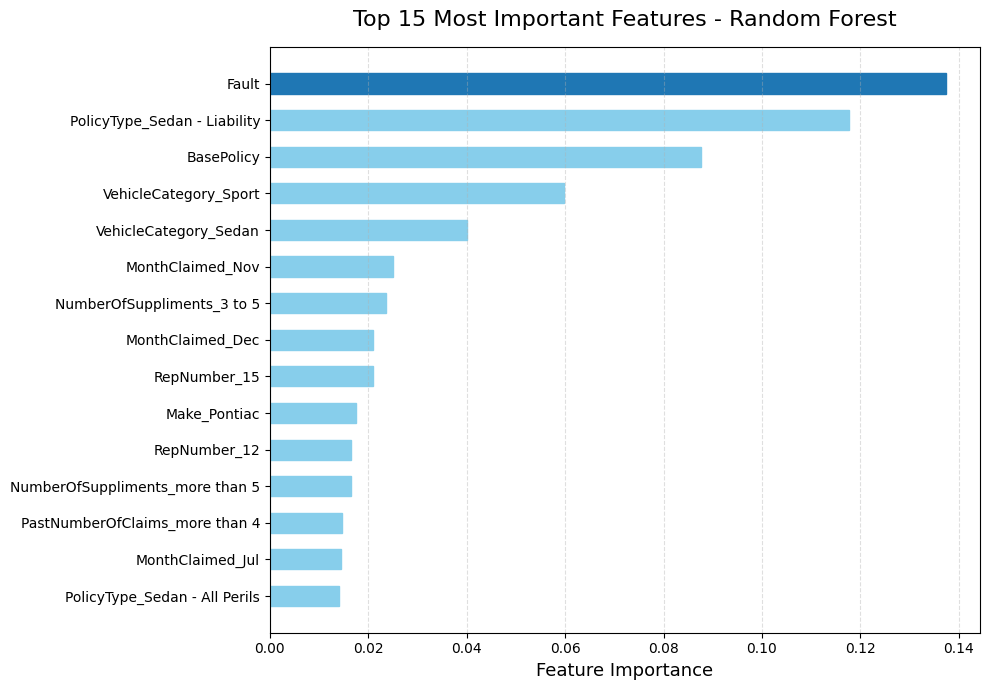

In [76]:
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

k = 15
top_indices = indices[:15]

plt.figure(figsize=(10, 7))

bars = plt.barh(feature_names[top_indices][::-1], importances[top_indices][::-1], height=0.55)

bars[-1].set_color('#1f77b4')

for bar in bars[:-1]:
  bar.set_color('#87ceeb')

plt.xlabel("Feature Importance", fontsize=13)
plt.title(f"Top {k} Most Important Features - Random Forest", fontsize=16, pad=15)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

In [70]:
idx = np.argmax(importances)
most_important_feature = X.columns[idx]
most_important_value = importances[idx]

print(f"Most Important Feature: {most_important_feature}")
print(f"Importance: {most_important_value}")


Most Important Feature: Fault
Importance: 0.13743598704924964


In [79]:
report = classification_report(y_test, y_pred, output_dict=True)
df = pd.DataFrame(report).transpose()
df

,precision,recall,f1-score,support
0,0.953924,0.824869,0.884715,2284.000000
1,0.840256,0.958542,0.895510,2195.000000
accuracy,0.890377,0.890377,0.890377,0.890377
macro avg,0.897090,0.891705,0.890112,4479.000000
weighted avg,0.898219,0.890377,0.890005,4479.000000


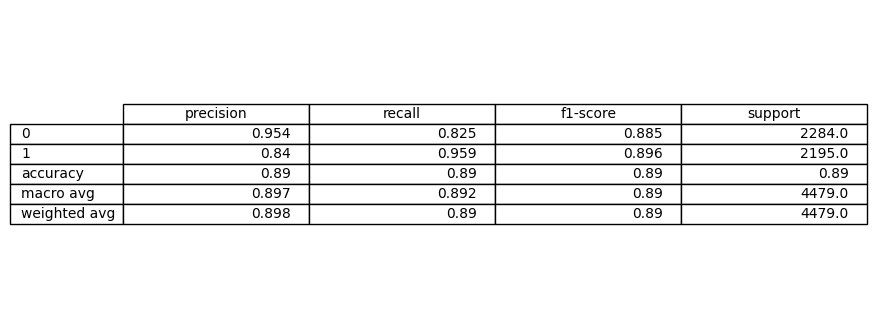

In [80]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')

table = ax.table(cellText=df.round(3).values, colLabels=df.columns, rowLabels=df.index, loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

plt.show()